In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv('final.csv')
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (39670, 89)
   dst_port protocol  duration  total_bytes  total_packets  fwd_pkts  fwd_bytes  fwd_pkt_len_mean  fwd_pkt_len_std  fwd_pkt_len_min  fwd_pkt_len_max  fwd_iat_mean  fwd_iat_std  fwd_iat_min  \
0       443      TCP  0.414215         4391             18         9       1069          118.7778          96.0599             54.0            331.0      0.051777     0.060601     0.000052   
1       443      TCP  0.058407         4369             17         9       1101          122.3333          98.8849             54.0            331.0      0.007301     0.008833     0.000067   
2       443      TCP  0.038559         4261             15         8       1047          130.8750         101.7048             54.0            331.0      0.005508     0.008076     0.000184   
3       443      TCP  0.037885         4261             15         8       1047          130.8750         101.7048             54.0            331.0      0.005412     0.008064     0.000093   
4       443      TCP 

In [2]:
df = df[df["label"] != "dreambot"].reset_index(drop=True)
df = df[df["label"] != "minor_project"].reset_index(drop=True)


In [3]:
print(df['label'].value_counts())

label
emotet      13977
benign      11538
trickbot    10904
Name: count, dtype: int64


In [4]:
# Cell 2: Keep only your selected features
features = [
    "protocol",
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_fingerprint",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "ja3_fingerprint",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts",
    "label"
]

missing_cols = [c for c in features if c not in df.columns]
print("Missing columns:", missing_cols)

df = df[features].copy()
print("New shape:", df.shape)
print(df.head())

Missing columns: []


New shape: (36419, 28)
  protocol  duration  total_bytes  total_packets  bytes_per_second  packets_per_second  pkt_len_mean  pkt_len_std  iat_mean   iat_std  burstiness  burst_count  is_complete_handshake  has_tls  \
0      TCP  0.054227          384              5         7081.3432             92.2050          76.8      34.0259  0.013557  0.023228      1.7134            1                      0        1   
1      TCP  0.000531          416              5       783427.4953           9416.1959          83.2      46.7093  0.000133  0.000092      0.6950            1                      0        1   
2      TCP  0.000530          416              5       784905.6603           9433.9623          83.2      46.7093  0.000133  0.000088      0.6624            1                      0        1   
3      TCP  0.000576          408              5       708333.3333           8680.5556          81.6      47.3354  0.000144  0.000076      0.5253            1                      0        1   
4      

In [5]:
# Cell 3: Basic cleaning checks
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After drop_duplicates:", df.duplicated().sum())

print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("Label counts:")
print(df["label"].value_counts())
print("Label proportions:")
print(df["label"].value_counts(normalize=True).round(4))

Duplicate rows: 3183
After drop_duplicates: 0
Missing values:
protocol                 0
duration                 0
total_bytes              0
total_packets            0
bytes_per_second         0
packets_per_second       0
pkt_len_mean             0
pkt_len_std              0
iat_mean                 0
iat_std                  0
burstiness               0
burst_count              0
is_complete_handshake    0
has_tls                  0
tls_cipher_count         0
tls_ext_count            0
ja4_fingerprint          0
ja4_tls_ver_num          0
ja4_cipher_count         0
ja4_ext_count            0
ja4_sni_present          0
ja4_has_alpn             0
ja3_fingerprint          0
dns_query_count          0
dns_unique_queries       0
http_request_count       0
http_unique_hosts        0
label                    0
dtype: int64
Label counts:
label
emotet      13972
trickbot    10904
benign       8360
Name: count, dtype: int64
Label proportions:
label
emotet      0.4204
trickbot    0.3281
benign

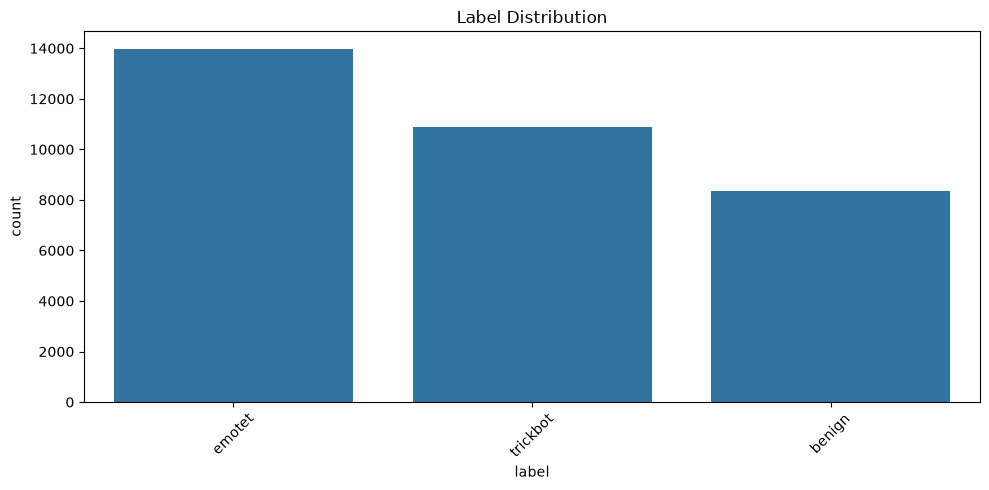

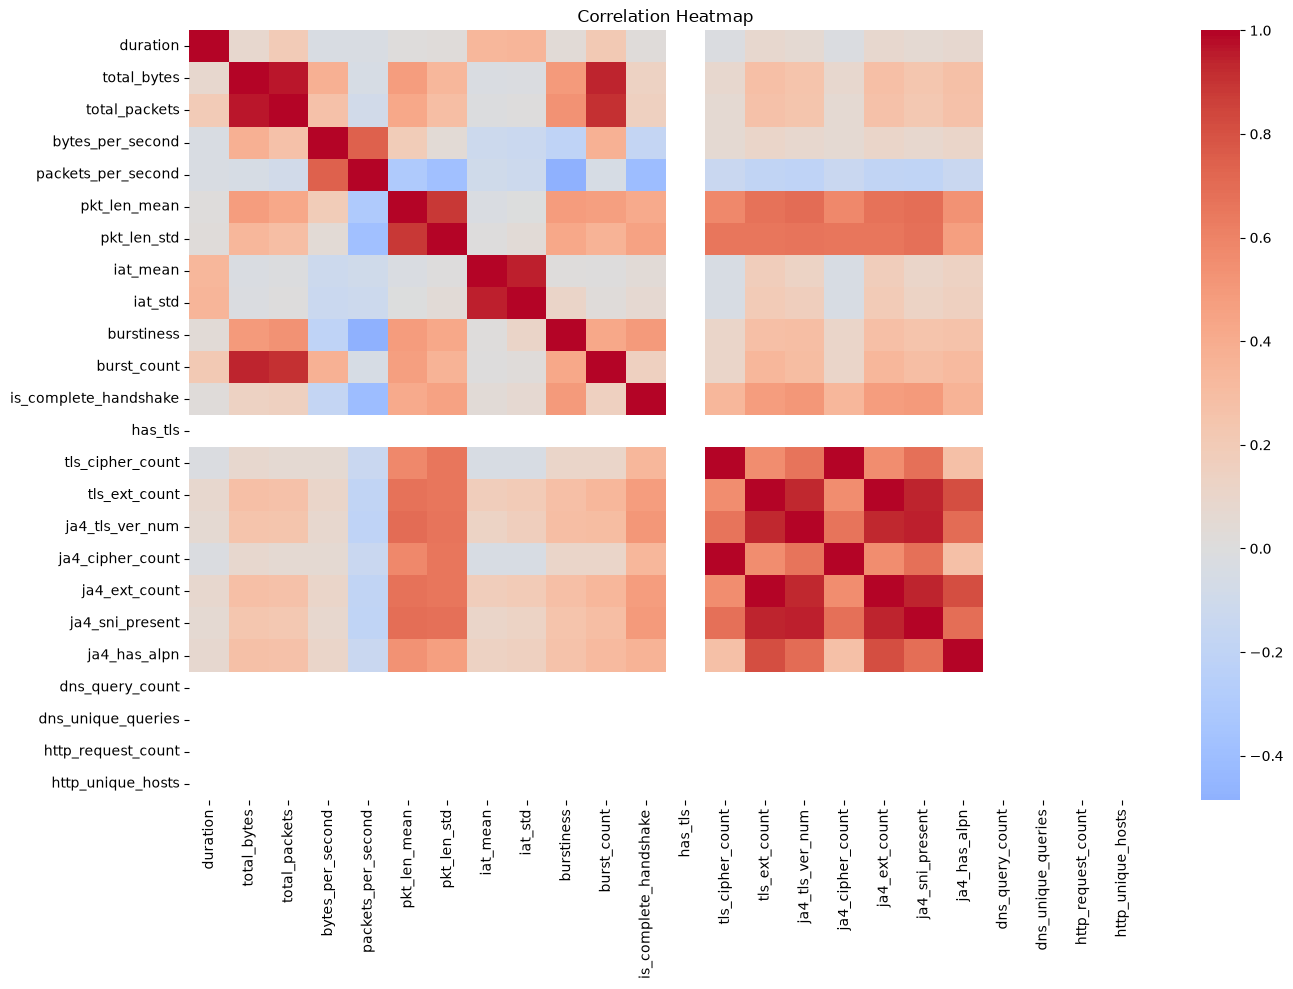

In [6]:
# Cell 4: EDA plots
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

top_missing = df.isnull().sum().sort_values(ascending=False)
top_missing = top_missing[top_missing > 0]

if len(top_missing) > 0:
    plt.figure(figsize=(12, 5))
    top_missing.head(20).plot(kind="bar")
    plt.title("Top Missing Columns")
    plt.ylabel("Missing Count")
    plt.tight_layout()
    plt.show()

In [7]:
# ============================================================
# Cell 5 (structural JA4 encoding version)
# Labels used: emotet, trickbot  (2-class, matches your current data)
# ============================================================

import re

X = df.drop(columns=["label"]).copy()
y = df["label"].copy()

print("Label counts going into this cell:")
print(y.value_counts())

# --- Fill missing values (pandas-version-safe) ---
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("unknown")

# --- Optional flags for sparse fingerprint fields ---
if "ja4_fingerprint" in X.columns:
    X["has_ja4"] = (X["ja4_fingerprint"] != "unknown").astype(int)
if "ja3_fingerprint" in X.columns:
    X["has_ja3"] = (X["ja3_fingerprint"] != "unknown").astype(int)


# ============================================================
# JA4 STRUCTURAL (character) ENCODING
# Splits t12i210300_b973bfd88a0e_c08b0bbc99a6 into its real parts
# instead of treating the whole string as one opaque ID.
# ============================================================

PROTOCOL_VOCAB = {"t": 0, "q": 1}
TLS_VERSION_VOCAB = {
    "13": 0, "12": 1, "11": 2, "10": 3,
    "s3": 4, "s2": 5, "s1": 6, "d3": 7, "d2": 8, "d1": 9, "00": 10,
}
ALPN_VOCAB = {"00": 0, "h1": 1, "h2": 2, "h3": 3, "ht": 4, "d2": 5}
N_HASH_BUCKETS = 256

def parse_ja4(fp: str) -> dict:
    if not isinstance(fp, str) or "_" not in fp or fp == "unknown":
        return None
    parts = fp.split("_")
    if len(parts) != 3 or len(parts[0]) < 10:
        return None
    a, b, c = parts
    return {
        "protocol": PROTOCOL_VOCAB.get(a[0], -1),
        "tls_version": TLS_VERSION_VOCAB.get(a[1:3], -1),
        "sni_present": 1 if a[3] == "d" else 0,
        "cipher_count": int(re.sub(r"\D", "", a[4:6]) or 0),
        "ext_count": int(re.sub(r"\D", "", a[6:8]) or 0),
        "alpn": ALPN_VOCAB.get(a[8:10], -1),
        "cipher_hash_bucket": int(b, 16) % N_HASH_BUCKETS if b else 0,
        "ext_hash_bucket": int(c, 16) % N_HASH_BUCKETS if c else 0,
    }

JA4_SUBFEATURES = [
    "ja4_protocol", "ja4_tls_version_parsed", "ja4_sni_present_parsed",
    "ja4_cipher_count_parsed", "ja4_ext_count_parsed", "ja4_alpn",
    "ja4_cipher_hash_bucket", "ja4_ext_hash_bucket",
]

if "ja4_fingerprint" in X.columns:
    parsed = X["ja4_fingerprint"].map(parse_ja4)
    for i, feat_name in enumerate(JA4_SUBFEATURES):
        key = list(parse_ja4.__annotations__) if False else None  # (no-op, keeps linters quiet)
    keys = ["protocol", "tls_version", "sni_present", "cipher_count",
            "ext_count", "alpn", "cipher_hash_bucket", "ext_hash_bucket"]
    for feat_name, key in zip(JA4_SUBFEATURES, keys):
        X[feat_name] = parsed.map(lambda p, k=key: p[k] if p else -1)

    # drop the raw string now that it's been decomposed
    X = X.drop(columns=["ja4_fingerprint"])
    print(f"ja4_fingerprint -> expanded into {len(JA4_SUBFEATURES)} structural features:")
    print(JA4_SUBFEATURES)

# --- JA3 stays as a plain ID (flat hash, no internal structure to parse) ---
UNKNOWN_ID = -1
def fit_id_map(series, mask):
    return {val: i for i, val in enumerate(sorted(series[mask].dropna().unique()))}
def apply_id_map(series, id_map):
    return series.map(lambda v: id_map.get(v, UNKNOWN_ID))

if "ja3_fingerprint" in X.columns:
    all_rows_mask = pd.Series(True, index=X.index)
    ja3_id_map = fit_id_map(X["ja3_fingerprint"], all_rows_mask)
    X["ja3_fingerprint"] = apply_id_map(X["ja3_fingerprint"], ja3_id_map)
    print(f"ja3_fingerprint -> {len(ja3_id_map)} unique IDs")

# protocol column (the flow-level one, not JA4's internal protocol byte)
if "protocol" in X.columns:
    X["protocol"] = pd.factorize(X["protocol"])[0]

# --- Encode target ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

print("\nClasses:", list(label_encoder.classes_))
print("X shape:", X.shape)
print("y shape:", y_categorical.shape)
print("\nFinal columns:", X.columns.tolist())

Label counts going into this cell:
label
emotet      13972
trickbot    10904
benign       8360
Name: count, dtype: int64
ja4_fingerprint -> expanded into 8 structural features:
['ja4_protocol', 'ja4_tls_version_parsed', 'ja4_sni_present_parsed', 'ja4_cipher_count_parsed', 'ja4_ext_count_parsed', 'ja4_alpn', 'ja4_cipher_hash_bucket', 'ja4_ext_hash_bucket']
ja3_fingerprint -> 2326 unique IDs

Classes: ['benign', 'emotet', 'trickbot']
X shape: (33236, 36)
y shape: (33236, 3)

Final columns: ['protocol', 'duration', 'total_bytes', 'total_packets', 'bytes_per_second', 'packets_per_second', 'pkt_len_mean', 'pkt_len_std', 'iat_mean', 'iat_std', 'burstiness', 'burst_count', 'is_complete_handshake', 'has_tls', 'tls_cipher_count', 'tls_ext_count', 'ja4_tls_ver_num', 'ja4_cipher_count', 'ja4_ext_count', 'ja4_sni_present', 'ja4_has_alpn', 'ja3_fingerprint', 'dns_query_count', 'dns_unique_queries', 'http_request_count', 'http_unique_hosts', 'has_ja4', 'has_ja3', 'ja4_protocol', 'ja4_tls_version_par

In [8]:
# ============================================================
# Cell 7: Diagnostic — how separable are fingerprints by class?
# ============================================================
diag = df.copy()
fp_by_label = diag.groupby("label")[["ja4_fingerprint", "ja3_fingerprint"]].nunique()
print("Unique fingerprints per class:\n", fp_by_label)

ja4_sets = diag.groupby("label")["ja4_fingerprint"].apply(set)
ja3_sets = diag.groupby("label")["ja3_fingerprint"].apply(set)
print("\nJA4 fingerprints shared between classes:", len(ja4_sets["emotet"] & ja4_sets["trickbot"]))
print("JA3 fingerprints shared between classes:", len(ja3_sets["emotet"] & ja3_sets["trickbot"]))
print("\nIf these numbers are tiny relative to total unique values, your fingerprint")
print("columns are acting as a near-direct label lookup, not a behavioral signal.")

Unique fingerprints per class:
           ja4_fingerprint  ja3_fingerprint
label                                     
benign               2318             2318
emotet                  7                7
trickbot                2                2

JA4 fingerprints shared between classes: 1
JA3 fingerprints shared between classes: 1

If these numbers are tiny relative to total unique values, your fingerprint
columns are acting as a near-direct label lookup, not a behavioral signal.


In [9]:
# ============================================================
# Cell 8: Split / scale (unchanged from your Cell 7)
# ============================================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_categorical, test_size=0.30, stratify=y_encoded, random_state=42
)
y_temp_labels = y_temp.argmax(axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp_labels, random_state=42
)

print("Split sizes:")
print("  train:", X_train.shape, y_train.shape)
print("  val:  ", X_val.shape, y_val.shape)
print("  test: ", X_test.shape, y_test.shape)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
X_train_cnn = X_train_scaled.reshape(-1, n_features, 1)
X_val_cnn = X_val_scaled.reshape(-1, n_features, 1)
X_test_cnn = X_test_scaled.reshape(-1, n_features, 1)

num_classes = y_categorical.shape[1]
print("\nnum_classes:", num_classes, "| n_features:", n_features)

Split sizes:
  train: (23265, 36) (23265, 3)
  val:   (4985, 36) (4985, 3)
  test:  (4986, 36) (4986, 3)

num_classes: 3 | n_features: 36


In [10]:
# ============================================================
# Cell 9: Class weights (from the integer labels, not one-hot)
# ============================================================
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = y_train.argmax(axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = dict(zip(np.unique(y_train_labels), class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.3251879699248121), np.int64(1): np.float64(0.7929447852760736), np.int64(2): np.float64(1.0159832307087646)}


In [11]:
# ============================================================
# Cell 10: Model + training (regularized, class-weighted)
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

def build_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(16, kernel_size=3, activation='relu', padding='same',
               kernel_regularizer=l2(0.02), input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.4),

        Conv1D(32, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.02)),
        BatchNormalization(),
        Dropout(0.4),

        Flatten(),
        Dense(32, activation='relu', kernel_regularizer=l2(0.02)),
        BatchNormalization(),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

model = build_model((n_features, 1), num_classes)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=40,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

c:\Users\lenovo\OneDrive\Desktop\minor project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8935 - loss: 1.3718 - val_accuracy: 0.9675 - val_loss: 0.9090 - learning_rate: 5.0000e-04
Epoch 2/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9610 - loss: 0.5009 - val_accuracy: 0.9673 - val_loss: 0.3224 - learning_rate: 5.0000e-04
Epoch 3/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9657 - loss: 0.2714 - val_accuracy: 0.9771 - val_loss: 0.2446 - learning_rate: 5.0000e-04
Epoch 4/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9728 - loss: 0.1856 - val_accuracy: 0.9769 - val_loss: 0.1544 - learning_rate: 5.0000e-04
Epoch 5/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9767 - loss: 0.1481 - val_accuracy: 0.9834 - val_loss: 0.1088 - learning_rate: 5.0000e-04
Epoch 6/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9794 - loss: 0.1260 - val_accuracy: 0.9854 - val_loss: 0.0974 - learning_rate: 5.0000e-04
Epoch 7/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Test Accuracy (WITH fingerprints): 99.46%
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      1254
      emotet       0.99      0.99      0.99      2096
    trickbot       1.00      0.99      0.99      1636

    accuracy                           0.99      4986
   macro avg       0.99      1.00      0.99      4986
weighted avg       0.99      0.99      0.99      4986



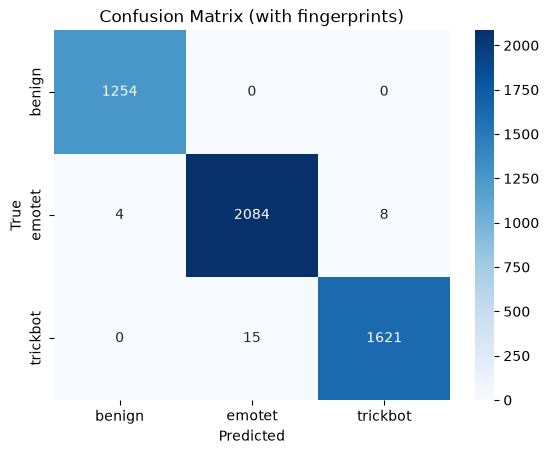

In [12]:
# ============================================================
# Cell 11: Evaluate on held-out TEST set (not val)
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = model.predict(X_test_cnn)
y_pred = y_pred_probs.argmax(axis=1)
y_test_labels = y_test.argmax(axis=1)

print(f"\nTest Accuracy (WITH fingerprints): {accuracy_score(y_test_labels, y_pred)*100:.2f}%")
print(classification_report(y_test_labels, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (with fingerprints)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

In [13]:
# ============================================================
# Cell 12: ABLATION — same pipeline, fingerprint columns removed
# This tells you how good the model is at BEHAVIORAL detection alone.
# ============================================================
fp_cols_to_drop = [c for c in X.columns if c.startswith("ja4_") or c.startswith("ja3_") or c in ("has_ja4", "has_ja3")]
print("Dropping for ablation:", fp_cols_to_drop)

X_no_fp = X.drop(columns=fp_cols_to_drop)

Xnf_train, Xnf_temp, ynf_train, ynf_temp = train_test_split(
    X_no_fp, y_categorical, test_size=0.30, stratify=y_encoded, random_state=42
)
ynf_temp_labels = ynf_temp.argmax(axis=1)
Xnf_val, Xnf_test, ynf_val, ynf_test = train_test_split(
    Xnf_temp, ynf_temp, test_size=0.50, stratify=ynf_temp_labels, random_state=42
)

scaler_nf = MinMaxScaler()
Xnf_train_s = scaler_nf.fit_transform(Xnf_train)
Xnf_val_s = scaler_nf.transform(Xnf_val)
Xnf_test_s = scaler_nf.transform(Xnf_test)

nf_features = Xnf_train_s.shape[1]
Xnf_train_cnn = Xnf_train_s.reshape(-1, nf_features, 1)
Xnf_val_cnn = Xnf_val_s.reshape(-1, nf_features, 1)
Xnf_test_cnn = Xnf_test_s.reshape(-1, nf_features, 1)

ynf_train_labels = ynf_train.argmax(axis=1)
nf_class_weights = compute_class_weight('balanced', classes=np.unique(ynf_train_labels), y=ynf_train_labels)
nf_class_weight_dict = dict(zip(np.unique(ynf_train_labels), nf_class_weights))

model_nf = build_model((nf_features, 1), num_classes)
model_nf.fit(
    Xnf_train_cnn, ynf_train,
    validation_data=(Xnf_val_cnn, ynf_val),
    epochs=40, batch_size=64,
    class_weight=nf_class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

ynf_pred = model_nf.predict(Xnf_test_cnn).argmax(axis=1)
ynf_test_labels = ynf_test.argmax(axis=1)
print(f"\nTest Accuracy (WITHOUT fingerprints, behavior only): {accuracy_score(ynf_test_labels, ynf_pred)*100:.4f}%")
print(classification_report(ynf_test_labels, ynf_pred, target_names=label_encoder.classes_))

Dropping for ablation: ['ja4_tls_ver_num', 'ja4_cipher_count', 'ja4_ext_count', 'ja4_sni_present', 'ja4_has_alpn', 'ja3_fingerprint', 'has_ja4', 'has_ja3', 'ja4_protocol', 'ja4_tls_version_parsed', 'ja4_sni_present_parsed', 'ja4_cipher_count_parsed', 'ja4_ext_count_parsed', 'ja4_alpn', 'ja4_cipher_hash_bucket', 'ja4_ext_hash_bucket']
Epoch 1/40


c:\Users\lenovo\OneDrive\Desktop\minor project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


364/364 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8963 - loss: 1.2524 - val_accuracy: 0.9625 - val_loss: 0.7980 - learning_rate: 5.0000e-04
Epoch 2/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9588 - loss: 0.4530 - val_accuracy: 0.9787 - val_loss: 0.3232 - learning_rate: 5.0000e-04
Epoch 3/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9664 - loss: 0.2618 - val_accuracy: 0.9807 - val_loss: 0.1904 - learning_rate: 5.0000e-04
Epoch 4/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9729 - loss: 0.1856 - val_accuracy: 0.9797 - val_loss: 0.1349 - learning_rate: 5.0000e-04
Epoch 5/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9739 - loss: 0.1566 - val_accuracy: 0.9797 - val_loss: 0.1118 - learning_rate: 5.0000e-04
Epoch 6/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9749 - loss: 0.1378 - val_accuracy: 0.9819 - val_loss: 0.1012 - learning_rate: 5.0000e-04
Epoch 7/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9761 - l